# 01 — Analiza danych treningowych

Notebook bada plik CSV wygenerowany przez Rust (`pipeline --gen-train-data`).  
Cel: zrozumieć rozkład cech, jakość etykiet i potencjalne problemy przed treningiem modelu.

In [ ]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# Podaj sciezke do pojedynczego pliku CSV lub folderu z wieloma plikami CSV.
# Przyklad (jeden genom):   Path("../../data/training/ecoli_training.csv")
# Przyklad (wiele genomow): Path("../../data/training/")
DATA_PATH = Path("../../data/training/")
BASES = ["A", "C", "G", "T"]
NULL_VALS = ["NA", "na", "NaN", "nan", ""]


def load_data(path: Path) -> pl.DataFrame:
    """Wczytaj jeden plik CSV lub wszystkie pliki CSV z folderu.

    Dodaje kolumne 'source_genome' (nazwa pliku bez rozszerzenia) i
    offsetuje junction_id per plik tak zeby byly globalnie unikalne.
    """
    path = Path(path)
    if path.is_dir():
        files = sorted(path.glob("*.csv"))
        if not files:
            raise FileNotFoundError(f"Brak plikow CSV w: {path}")
        parts = []
        for i, f in enumerate(files):
            part = pl.read_csv(f, null_values=NULL_VALS)
            part = part.with_columns([
                pl.lit(f.stem).alias("source_genome"),
                (pl.col("junction_id") + i * 1_000_000).alias("junction_id"),
            ])
            parts.append(part)
        print(f"Wczytano {len(files)} plikow: {[f.name for f in files]}")
        return pl.concat(parts, how="diagonal_relaxed")
    else:
        if not path.exists():
            raise FileNotFoundError(f"Plik nie istnieje: {path}")
        df = pl.read_csv(path, null_values=NULL_VALS)
        return df.with_columns(pl.lit(path.stem).alias("source_genome"))

## 1. Wczytanie surowego CSV

In [ ]:
raw = load_data(DATA_PATH)
print(f"Wiersze: {raw.height}   Kolumny: {raw.width}")
raw.head(3)

In [ ]:
# Statystyki per genom (widoczne tylko przy wczytaniu folderu z wieloma plikami)
if "source_genome" in raw.columns:
    per_genome = (
        raw.group_by("source_genome")
        .agg([
            pl.len().alias("total"),
            (pl.col("gt_ambiguous").cast(pl.Utf8).str.to_lowercase() == "true").sum().alias("ambiguous"),
            ((pl.col("gt_ambiguous").cast(pl.Utf8).str.to_lowercase() != "true")
             & pl.col("ground_truth").is_not_null()).sum().alias("labeled"),
        ])
        .sort("source_genome")
    )
    print("Wiersze per genom:")
    print(per_genome)

In [3]:
# Typy i przykładowe wartości
raw.schema

Schema([('junction_id', Int64),
        ('contig_id', Int64),
        ('depth_in_contig', Int64),
        ('out_degree', Int64),
        ('in_degree', Int64),
        ('node_seq', String),
        ('context_seq', String),
        ('branch_A_seq', String),
        ('branch_A_cov', Int64),
        ('branch_C_seq', String),
        ('branch_C_cov', Int64),
        ('branch_G_seq', String),
        ('branch_G_cov', Int64),
        ('branch_T_seq', String),
        ('branch_T_cov', Int64),
        ('ground_truth', String),
        ('gt_ambiguous', Boolean),
        ('cov_ratio_max', Float64),
        ('total_reads', Int64)])

## 2. Klasyfikacja wierszy: labeled / ambiguous / no-ground-truth

In [4]:
df = raw.with_columns([
    pl.col("gt_ambiguous").cast(pl.Utf8).str.to_lowercase().alias("gt_ambiguous_str"),
])

n_total     = df.height
n_ambiguous = df.filter(pl.col("gt_ambiguous_str") == "true").height
n_labeled   = df.filter(
    (pl.col("gt_ambiguous_str") == "false") & pl.col("ground_truth").is_not_null()
).height
n_no_gt     = n_total - n_ambiguous - n_labeled

print(f"Łącznie:             {n_total}")
print(f"Labeled (GT znany):  {n_labeled}  ({n_labeled/n_total*100:.1f}%)")
print(f"Ambiguous:           {n_ambiguous}  ({n_ambiguous/n_total*100:.1f}%)")
print(f"Brak ground-truth:   {n_no_gt}  ({n_no_gt/n_total*100:.1f}%)")

Łącznie:             703
Labeled (GT znany):  152  (21.6%)
Ambiguous:           551  (78.4%)
Brak ground-truth:   0  (0.0%)


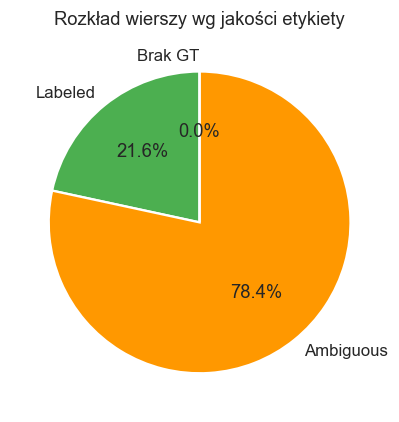

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = [n_labeled, n_ambiguous, n_no_gt]
labels = ["Labeled", "Ambiguous", "Brak GT"]
colors = ["#4CAF50", "#FF9800", "#9E9E9E"]
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Rozkład wierszy wg jakości etykiety", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Dalsze analizy na wierszach z etykietą

In [6]:
labeled = df.filter(
    (pl.col("gt_ambiguous_str") == "false") & pl.col("ground_truth").is_not_null()
).with_columns([
    pl.col("ground_truth").cast(pl.Utf8).str.to_uppercase().alias("ground_truth"),
    pl.col("context_seq").fill_null("").str.len_chars().alias("context_len"),
    pl.col("out_degree").cast(pl.Int32, strict=False).alias("out_degree"),
    pl.col("total_reads").cast(pl.Int64, strict=False).alias("total_reads"),
    pl.col("cov_ratio_max").cast(pl.Float32, strict=False).alias("cov_ratio_max"),
] + [
    pl.col(f"branch_{b}_seq").fill_null("").str.len_chars().alias(f"branch_{b}_len")
    for b in BASES
] + [
    pl.col(f"branch_{b}_cov").cast(pl.Float32, strict=False).alias(f"branch_{b}_cov")
    for b in BASES
])

labeled = labeled.with_columns(
    pl.max_horizontal([f"branch_{b}_len" for b in BASES]).alias("max_branch_len")
)

print(f"Labeled wierszy: {labeled.height}")
labeled.select(["junction_id", "ground_truth", "context_len", "max_branch_len",
                "out_degree", "total_reads", "cov_ratio_max"]).head(5)

Labeled wierszy: 152


junction_id,ground_truth,context_len,max_branch_len,out_degree,total_reads,cov_ratio_max
i64,str,u32,u32,i32,i64,f32
0,"""T""",62,31,2,59,0.5763
4,"""T""",100,100,2,108,0.5556
16,"""A""",40,44,2,72,0.6806
22,"""G""",31,8,3,181,0.6464
24,"""G""",40,2,2,287,0.6585


### 3.1 Rozkład etykiet (ground truth)

shape: (4, 2)
┌──────────────┬───────┐
│ ground_truth ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ A            ┆ 40    │
│ C            ┆ 29    │
│ G            ┆ 49    │
│ T            ┆ 34    │
└──────────────┴───────┘


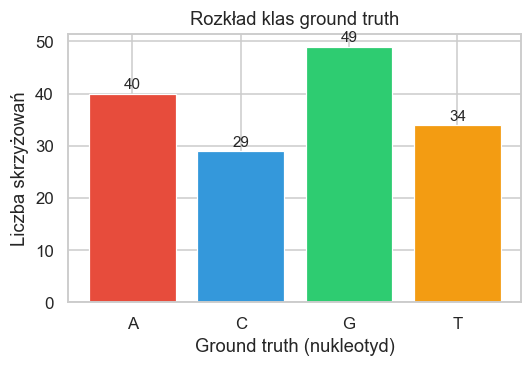

In [7]:
gt_counts = (
    labeled["ground_truth"]
    .value_counts()
    .sort("ground_truth")
)
print(gt_counts)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(gt_counts["ground_truth"].to_list(),
       gt_counts["count"].to_list(),
       color=["#e74c3c", "#3498db", "#2ecc71", "#f39c12"],
       edgecolor="white", linewidth=0.8)
ax.set_xlabel("Ground truth (nukleotyd)")
ax.set_ylabel("Liczba skrzyżowań")
ax.set_title("Rozkład klas ground truth")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### 3.2 Długości sekwencji kontekstu i gałęzi

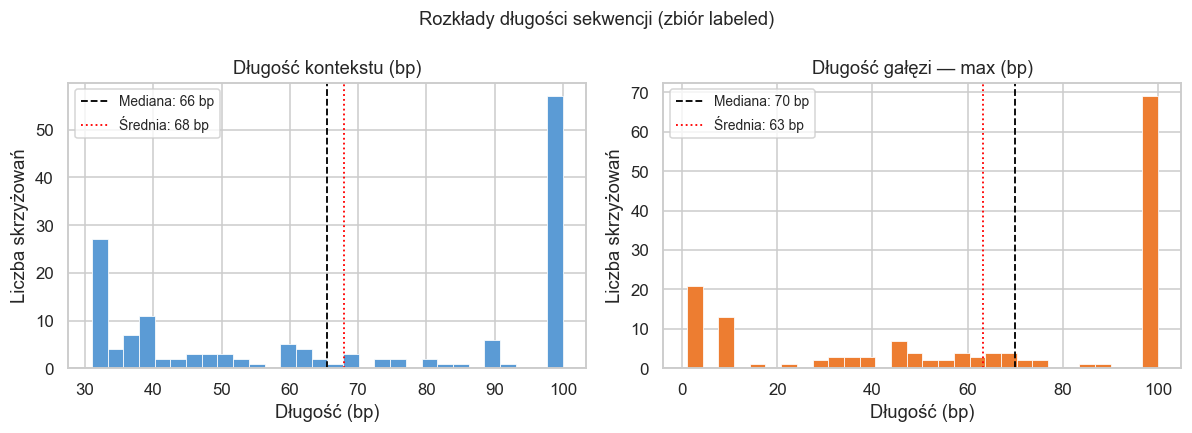

Kontekst — min=31 mediana=66 max=100
Gałąź   — min=1  mediana=70  max=100


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ctx_lens = labeled["context_len"].drop_nulls().to_numpy()
br_lens  = labeled["max_branch_len"].drop_nulls().to_numpy()

for ax, data, title, color in zip(
    axes,
    [ctx_lens, br_lens],
    ["Długość kontekstu (bp)", "Długość gałęzi — max (bp)"],
    ["#5b9bd5", "#ed7d31"],
):
    ax.hist(data, bins=30, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(np.median(data), color="black", linestyle="--", linewidth=1.2,
               label=f"Mediana: {np.median(data):.0f} bp")
    ax.axvline(np.mean(data), color="red", linestyle=":", linewidth=1.2,
               label=f"Średnia: {np.mean(data):.0f} bp")
    ax.set_title(title)
    ax.set_xlabel("Długość (bp)")
    ax.set_ylabel("Liczba skrzyżowań")
    ax.legend(fontsize=9)

plt.suptitle("Rozkłady długości sekwencji (zbiór labeled)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Kontekst — min={ctx_lens.min()} mediana={np.median(ctx_lens):.0f} max={ctx_lens.max()}")
print(f"Gałąź   — min={br_lens.min()}  mediana={np.median(br_lens):.0f}  max={br_lens.max()}")

### 3.3 Stopień wyjściowy węzłów (out-degree)

shape: (3, 2)
┌────────────┬───────┐
│ out_degree ┆ count │
│ ---        ┆ ---   │
│ i32        ┆ u32   │
╞════════════╪═══════╡
│ 2          ┆ 136   │
│ 3          ┆ 14    │
│ 4          ┆ 2     │
└────────────┴───────┘


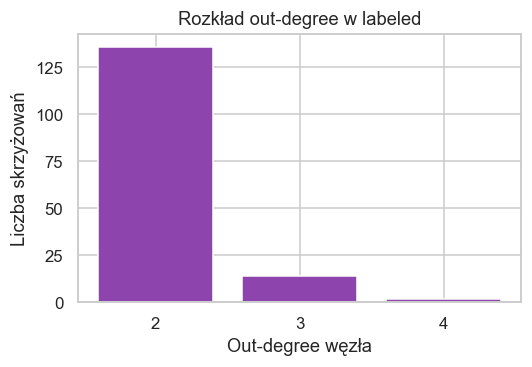

In [9]:
deg_counts = labeled["out_degree"].drop_nulls().value_counts().sort("out_degree")
print(deg_counts)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(
    deg_counts["out_degree"].cast(pl.Utf8).to_list(),
    deg_counts["count"].to_list(),
    color="#8e44ad", edgecolor="white",
)
ax.set_xlabel("Out-degree węzła")
ax.set_ylabel("Liczba skrzyżowań")
ax.set_title("Rozkład out-degree w labeled")
plt.tight_layout()
plt.show()

### 3.4 Pokrycie odczytów

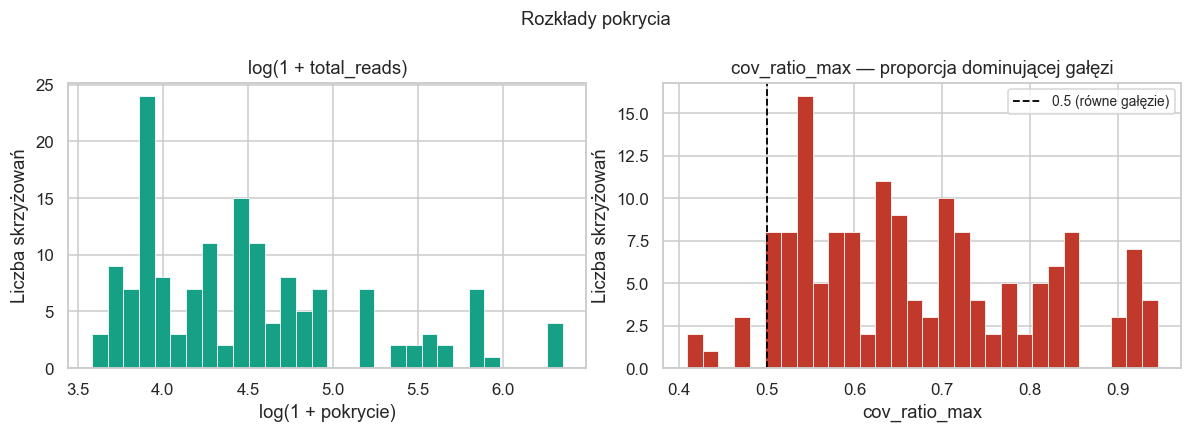

total_reads    — mediana=84  max=572
cov_ratio_max  — mediana=0.653  min=0.409  max=0.946


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Total reads
total = labeled["total_reads"].drop_nulls().to_numpy().astype(float)
axes[0].hist(np.log1p(total), bins=30, color="#16a085", edgecolor="white", linewidth=0.5)
axes[0].set_title("log(1 + total_reads)")
axes[0].set_xlabel("log(1 + pokrycie)")
axes[0].set_ylabel("Liczba skrzyżowań")

# cov_ratio_max
ratio = labeled["cov_ratio_max"].drop_nulls().to_numpy().astype(float)
axes[1].hist(ratio, bins=30, color="#c0392b", edgecolor="white", linewidth=0.5)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="0.5 (równe gałęzie)")
axes[1].set_title("cov_ratio_max — proporcja dominującej gałęzi")
axes[1].set_xlabel("cov_ratio_max")
axes[1].set_ylabel("Liczba skrzyżowań")
axes[1].legend(fontsize=9)

plt.suptitle("Rozkłady pokrycia", fontsize=12)
plt.tight_layout()
plt.show()

print(f"total_reads    — mediana={np.median(total):.0f}  max={total.max():.0f}")
print(f"cov_ratio_max  — mediana={np.median(ratio):.3f}  min={ratio.min():.3f}  max={ratio.max():.3f}")

### 3.5 Pokrycie per-gałąź (tylko aktywne)

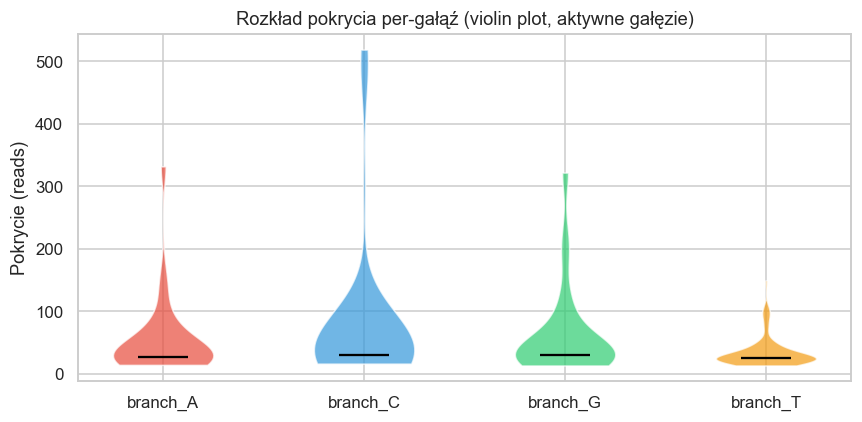

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

palette = {"A": "#e74c3c", "C": "#3498db", "G": "#2ecc71", "T": "#f39c12"}
offset = 0
all_covs, all_labels = [], []

for b in BASES:
    cov_col = f"branch_{b}_cov"
    vals = labeled[cov_col].drop_nulls().to_numpy().astype(float)
    vals = vals[vals > 0]
    all_covs.append(vals)
    all_labels.append(b)

vp = ax.violinplot(all_covs, positions=[1, 2, 3, 4], showmedians=True, showextrema=False)
for body, b in zip(vp["bodies"], BASES):
    body.set_facecolor(palette[b])
    body.set_alpha(0.7)
vp["cmedians"].set_color("black")

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([f"branch_{b}" for b in BASES])
ax.set_ylabel("Pokrycie (reads)")
ax.set_title("Rozkład pokrycia per-gałąź (violin plot, aktywne gałęzie)")
plt.tight_layout()
plt.show()

### 3.6 Sygnał pokrycia — czy dominująca gałąź to ground truth?

In [12]:
# Sprawdzamy, czy gałąź o najwyższym pokryciu zgadza się z ground truth
rows = labeled.select(
    ["ground_truth"] + [f"branch_{b}_cov" for b in BASES]
).to_dicts()

correct, total_valid = 0, 0
for row in rows:
    gt = row["ground_truth"]
    cov = {b: (row[f"branch_{b}_cov"] or 0.0) for b in BASES}
    best = max(cov, key=cov.get)
    if any(v > 0 for v in cov.values()):
        total_valid += 1
        if best == gt:
            correct += 1

print(f"Baseline (wybierz gałąź z max pokryciem):")
print(f"  Poprawne: {correct}/{total_valid}  ({correct/total_valid*100:.1f}%)")
print()
print("To górna granica prostego heurystyki — model powinien ją pobić.")

Baseline (wybierz gałąź z max pokryciem):
  Poprawne: 100/152  (65.8%)

To górna granica prostego heurystyki — model powinien ją pobić.


### 3.7 Długość kontekstu vs długość gałęzi (scatter)

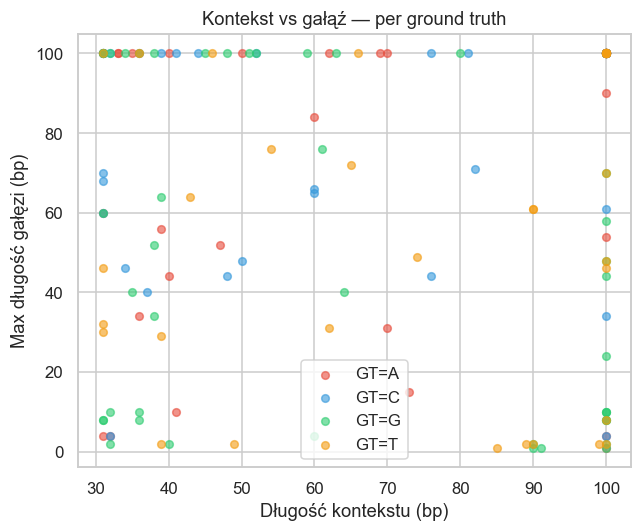

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))

for gt_base, color in palette.items():
    sub = labeled.filter(pl.col("ground_truth") == gt_base)
    ax.scatter(
        sub["context_len"].to_numpy(),
        sub["max_branch_len"].to_numpy(),
        color=color, alpha=0.6, s=25, label=f"GT={gt_base}",
    )

ax.set_xlabel("Długość kontekstu (bp)")
ax.set_ylabel("Max długość gałęzi (bp)")
ax.set_title("Kontekst vs gałąź — per ground truth")
ax.legend()
plt.tight_layout()
plt.show()

### 3.8 Liczba aktywnych gałęzi per skrzyżowanie

shape: (3, 2)
┌───────────────────┬───────┐
│ n_active_branches ┆ count │
│ ---               ┆ ---   │
│ i32               ┆ u32   │
╞═══════════════════╪═══════╡
│ 2                 ┆ 136   │
│ 3                 ┆ 14    │
│ 4                 ┆ 2     │
└───────────────────┴───────┘


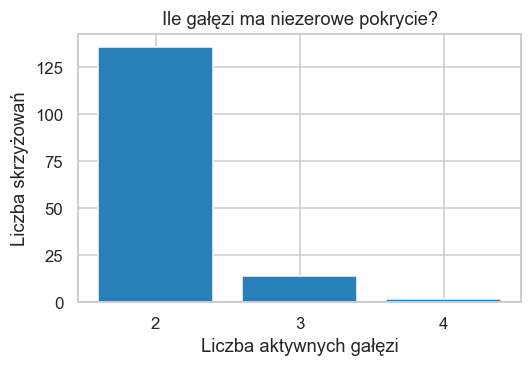

In [14]:
labeled2 = labeled.with_columns(
    pl.sum_horizontal([
        pl.col(f"branch_{b}_cov").is_not_null().cast(pl.Int32) for b in BASES
    ]).alias("n_active_branches")
)

branch_counts = labeled2["n_active_branches"].value_counts().sort("n_active_branches")
print(branch_counts)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(
    branch_counts["n_active_branches"].cast(pl.Utf8).to_list(),
    branch_counts["count"].to_list(),
    color="#2980b9", edgecolor="white",
)
ax.set_xlabel("Liczba aktywnych gałęzi")
ax.set_ylabel("Liczba skrzyżowań")
ax.set_title("Ile gałęzi ma niezerowe pokrycie?")
plt.tight_layout()
plt.show()

## 4. Analiza ambiguous — dlaczego tak dużo?

Skrzyżowania ambiguous to takie, gdzie dwie gałęzie mają porównywalne pokrycie lub brakuje jednoznacznego sygnału z referencji.

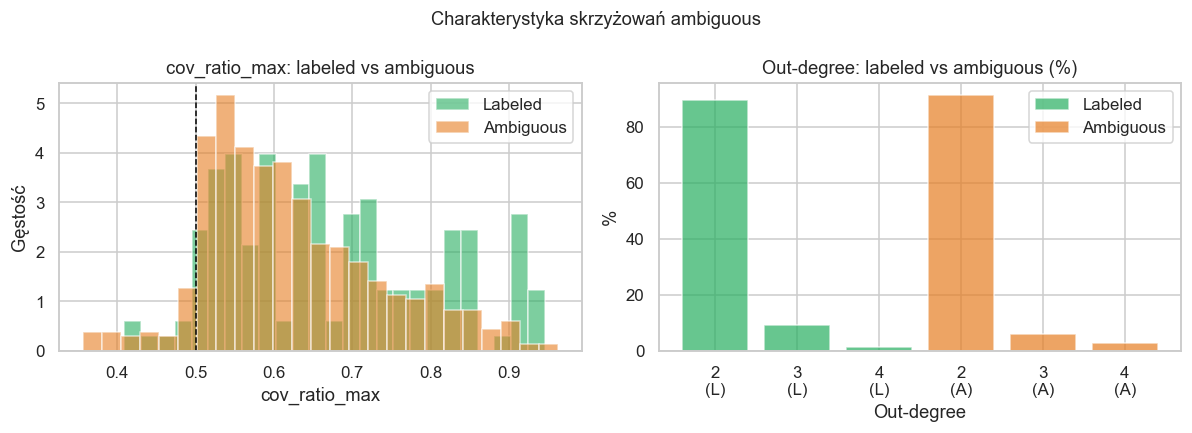

Mediana cov_ratio_max — labeled:   0.653
Mediana cov_ratio_max — ambiguous: 0.600


In [15]:
ambiguous = df.filter(pl.col("gt_ambiguous_str") == "true").with_columns([
    pl.col("cov_ratio_max").cast(pl.Float32, strict=False).alias("cov_ratio_max"),
    pl.col("out_degree").cast(pl.Int32, strict=False).alias("out_degree"),
    pl.col("total_reads").cast(pl.Int64, strict=False).alias("total_reads"),
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# cov_ratio_max — ambiguous vs labeled
r_amb = ambiguous["cov_ratio_max"].drop_nulls().to_numpy().astype(float)
r_lab = labeled["cov_ratio_max"].drop_nulls().to_numpy().astype(float)

axes[0].hist(r_lab, bins=25, alpha=0.6, color="#27ae60", label="Labeled", density=True)
axes[0].hist(r_amb, bins=25, alpha=0.6, color="#e67e22", label="Ambiguous", density=True)
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_title("cov_ratio_max: labeled vs ambiguous")
axes[0].set_xlabel("cov_ratio_max")
axes[0].set_ylabel("Gęstość")
axes[0].legend()

# out_degree — ambiguous vs labeled
for grp, color, label in [
    (labeled,   "#27ae60", "Labeled"),
    (ambiguous, "#e67e22", "Ambiguous"),
]:
    vc = grp["out_degree"].drop_nulls().value_counts().sort("out_degree")
    total = vc["count"].sum()
    axes[1].bar(
        [str(v) + f"\n({label[0]}" + ")" for v in vc["out_degree"].to_list()],
        (vc["count"] / total * 100).to_list(),
        alpha=0.7, color=color, label=label,
    )

axes[1].set_title("Out-degree: labeled vs ambiguous (%)")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("%")
axes[1].legend()

plt.suptitle("Charakterystyka skrzyżowań ambiguous", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mediana cov_ratio_max — labeled:   {np.median(r_lab):.3f}")
print(f"Mediana cov_ratio_max — ambiguous: {np.median(r_amb):.3f}")

## 5. Podsumowanie i wnioski

In [16]:
print("=" * 60)
print("PODSUMOWANIE")
print("=" * 60)
print(f"  Łącznie skrzyżowań:       {n_total}")
print(f"  Z etykietą (do treningu): {n_labeled}  ({n_labeled/n_total*100:.1f}%)")
print(f"  Ambiguous (odrzucone):    {n_ambiguous}  ({n_ambiguous/n_total*100:.1f}%)")
print()
print(f"  Mediana długości kontekstu: {np.median(ctx_lens):.0f} bp")
print(f"  Mediana długości gałęzi:    {np.median(br_lens):.0f} bp")
print()
print(f"  Baseline (max-coverage):    {correct/total_valid*100:.1f}%")
print()
print("Wnioski:")
print("  • Duża liczba ambiguous sugeruje, że obecne pokrycie (coverage)")
print("    jest niewystarczające lub algorytm GT jest zbyt konserwatywny.")
print("  • Baseline max-coverage pokazuje górną granicę heurystyki bez ML.")
print("  • Mała próba labeled (<200 wierszy) → augmentacja jest kluczowa,")
print("    a wyniki na val mogą być niestabilne.")
print("  • Rozważ zwiększenie --coverage w Rust pipeline (np. 50x → 100x).")

PODSUMOWANIE
  Łącznie skrzyżowań:       703
  Z etykietą (do treningu): 152  (21.6%)
  Ambiguous (odrzucone):    551  (78.4%)

  Mediana długości kontekstu: 66 bp
  Mediana długości gałęzi:    70 bp

  Baseline (max-coverage):    65.8%

Wnioski:
  • Duża liczba ambiguous sugeruje, że obecne pokrycie (coverage)
    jest niewystarczające lub algorytm GT jest zbyt konserwatywny.
  • Baseline max-coverage pokazuje górną granicę heurystyki bez ML.
  • Mała próba labeled (<200 wierszy) → augmentacja jest kluczowa,
    a wyniki na val mogą być niestabilne.
  • Rozważ zwiększenie --coverage w Rust pipeline (np. 50x → 100x).
